加载必要库

In [6]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt
s=ct.tf('s')

本段计算控制到输出的传输函数,参考Lee的模型,相关内容链接:https://www.notion.so/Flyback-253058cd607780b796d9dd75ed8c64f2
$$
\begin{align*}
&g_{vc}=g_{vc0}\dfrac{(1+\dfrac{s}{\omega_{esr}})(1-\dfrac{s}{\omega_{rhp}})}{(1+\dfrac{s}{\omega_{p1}})(1+\dfrac{s}{Q_1\omega_1}+\dfrac{s^2}{\omega_1^2})}\\
&\omega_{esr}=\dfrac{1}{R_{esr}C_o}\\[0.5cm]
&\omega_{P1}=\dfrac{1}{C_o(R_{esr}+R_{load})}\dfrac{1-k_2R_{load}}{1-\dfrac{k_2R_{load}R_{esr}}{R_{esr}+R_{load}}}\\[0.5cm]
&Q_1=\dfrac{1}{\pi(0.5+\dfrac{S_e-S_f}{S_n+S_f})}\\[0.5cm]
&\omega_1=\dfrac{\pi}{T_{sw}}\\[0.5cm]
&g_{vc0}=\dfrac{1}{R_{i}}\dfrac{DV_{IN}}{V_O}\dfrac{R_{load}}{1-k_2R_{load}}\\[0.5cm]
&k_2=-\dfrac{n^2(1-D)^3T_{sw}}{2L_m}-\dfrac{n(1-D)}{V_{in}+nV_O}(\dfrac{V_o}{(1-D)R_{load}}+\dfrac{n}{R_{i}}S_e(1-D)T_{sw})\\[0.5cm]
&D=\dfrac{nV_o}{V_{in}+nV_o}\\[0.5cm]
&S_n=\dfrac{R_iV_{in}}{L_m}\\[0.5cm]
&S_f=\dfrac{nR_iV_{o}}{L_m}\\[0.5cm]
&n=\dfrac{N_p}{N_s}
\end{align*}
$$

In [7]:
pi=3.1415926
ri=0.15
rload=1
vin=220
vout=10
ts=10e-6
n=6.5
lm=160e-6
se=1e6
cout=940e-6
resr=17.5e-3
d=n*vout/(vin+n*vout)
sn=ri*vin/lm
sf=ri*n*vout/lm
k2=-n*n*(1-d)*(1-d)*(1-d)*ts/2/lm-n*(1-d)/(vin+n*vout)*(vout/(1-d)/rload+n/ri*se*(1-d)*ts)
gvc0=(1/ri)*(d*vin/vout)*rload/(1-k2*rload)
wesr=1/resr/cout
wrhp=(1-d)*(1-d)*n*n*rload/d/lm
wp1=1/cout/(resr+rload)*(1-k2*rload)/(1-k2*rload*resr/(resr+rload))
q1=1/pi/(0.5+(se-sf)/(sn+sf))
w1=pi/ts
gvc=gvc0*(1+s/wesr)*(1-s/wrhp)/(1+s/wp1)/(1+s/q1/w1+s*s/w1/w1)
print("gvc0 =",gvc0)

gvc0 = 4.330446994708308


计算vout到vc的传输函数
$$
g_{ea}=g_m\frac{1+sR_{COMP}C_{COMP}}{sC_{COMP}}\\[0.5cm]
g_{OPTO}=\frac{CTR\cdot R_{OPTO}}{R_{LED}}\frac{1}{1+sR_{OPTO}C_{OPTO}}
$$

In [8]:
rfbt=90e3
rfbb=10e3
gm=12e-6
rcomp=70e3
ccomp=2.2e-9
ctr=0.25
ropto=22e3
rled=1e3
copto=2.2e-9
gea=gm*(1+s*rcomp*ccomp)/s/ccomp
gopto=ctr*ropto/rled/(1+s*ropto*copto)


本段计算总的传输函数
$$
g_{closed}=g_{vc}\frac{R_{FBB}}{R_{FBT}+R_{FBB}}g_{ea}g_{OPTO}\\[0.5cm]
$$

In [9]:
gclosed=gvc*rfbb/(rfbt+rfbb)*gea*gopto
print(gclosed)


         -7.833e+15 s^3 + 4.877e+21 s^2 + 3.605e+26 s + 2.133e+30
---------------------------------------------------------------------------
1.112e+07 s^5 + 4.439e+13 s^4 + 2.329e+18 s^3 + 3.722e+22 s^2 + 1.642e+26 s



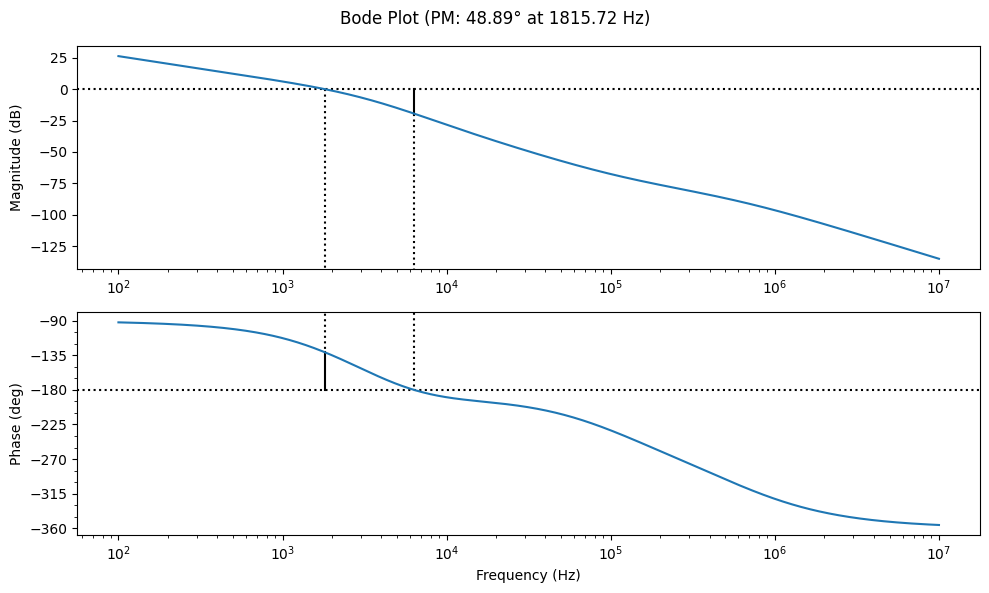

In [10]:
#Calculate Margins
gm, pm, wcg, wcp_rad = ct.margin(gclosed)
wcp_hz = wcp_rad / (2 * np.pi)
#Plot Bode Plot in Hz
plt.figure(figsize=(10, 6))
# dB=True for decibels, Hz=True to change x-axis from rad/s to Hz
ct.bode_plot(gclosed, dB=True, Hz=True, margins=True)

plt.suptitle(f"Bode Plot (PM: {pm:.2f}° at {wcp_hz:.2f} Hz)")
plt.tight_layout()
plt.show()